## Model Description

- **Linear Regression** is a supervised learning model used for predicting a continuous numerical target.
- It fits a straight-line relationship between the input features and the target variable.
- In this notebook, the model predicts `mpg` using car features such as weight, horsepower, displacement, and model year.
- **OLS** finds the best-fitting line by minimizing squared prediction errors.
- **Ridge Regression** adds L2 regularization, which shrinks coefficients and helps reduce overfitting.
- **Lasso Regression** adds L1 regularization, which can shrink some coefficients all the way to zero and perform feature selection.

In [1]:
import os
import urllib.request

DATA_DIR = (
    os.path.join(os.path.dirname(os.getcwd()), "data")
    if os.path.basename(os.getcwd()) == "notebooks"
    else "data"
)

os.makedirs(DATA_DIR, exist_ok=True)


def download_if_needed(url, filename):
    """Download a CSV if it doesn't already exist locally."""
    path = os.path.join(DATA_DIR, filename)

    if not os.path.exists(path):
        print(f"Downloading {filename} from {url}")
        urllib.request.urlretrieve(url, path)

    return path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
np.random.seed(42)


## 1. Load the data

In [2]:
path = download_if_needed(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/auto-mpg.csv",
    "auto-mpg.csv",
)

cols = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "name",
]

df = pd.read_csv(path, header=None, names=cols, na_values="?")

df = df.drop(columns="name").dropna()

print("Shape:", df.shape)

df.head()

Shape: (393, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
1,18,8,307,130,3504,12,70,1
2,15,8,350,165,3693,11.5,70,1
3,18,8,318,150,3436,11,70,1
4,16,8,304,150,3433,12,70,1


## 2. Exploratory Data Analysis

In [3]:
path = download_if_needed(
    "https://huggingface.co/datasets/scikit-learn/auto-mpg/resolve/main/auto-mpg.csv",
    "auto-mpg.csv",
)

df = pd.read_csv(path, na_values="?")

df = df.rename(
    columns={
        "model year": "model_year",
        "car name": "name",
    }
)

df = df.drop(columns="name").dropna()

print(df.columns)
df.head()


Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='object')


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


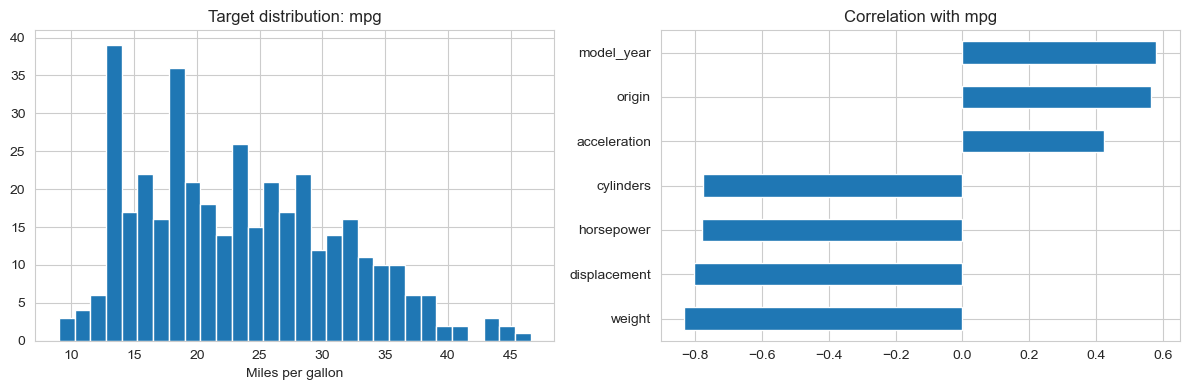

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df["mpg"].hist(bins=30, ax=ax[0])
ax[0].set_title("Target distribution: mpg")
ax[0].set_xlabel("Miles per gallon")

corr = df.corr(numeric_only=True)["mpg"].drop("mpg").sort_values()
corr.plot(kind="barh", ax=ax[1])
ax[1].set_title("Correlation with mpg")

plt.tight_layout()
plt.show()




As expected, **weight**, **displacement**, and **cylinders** correlate strongly *negatively* with mpg, while **model_year** correlates positively (newer cars are more efficient).

## 3. Train/test split + feature scaling

In [5]:
X = df.drop(columns="mpg").values
y = df["mpg"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")

Train: (313, 7), Test: (79, 7)


## 4. Compare three regression models

In [6]:
models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
}

results = []

for name, m in models.items():
    m.fit(X_train_s, y_train)
    preds = m.predict(X_test_s)

    results.append(
        {
            "Model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R^2": r2_score(y_test, preds),
        }
    )

pd.DataFrame(results).round(4)

,Model,RMSE,R^2
0,OLS,3.2727,0.7902
1,Ridge,3.2814,0.7890
2,Lasso,3.3026,0.7863


## 5. Coefficient inspection

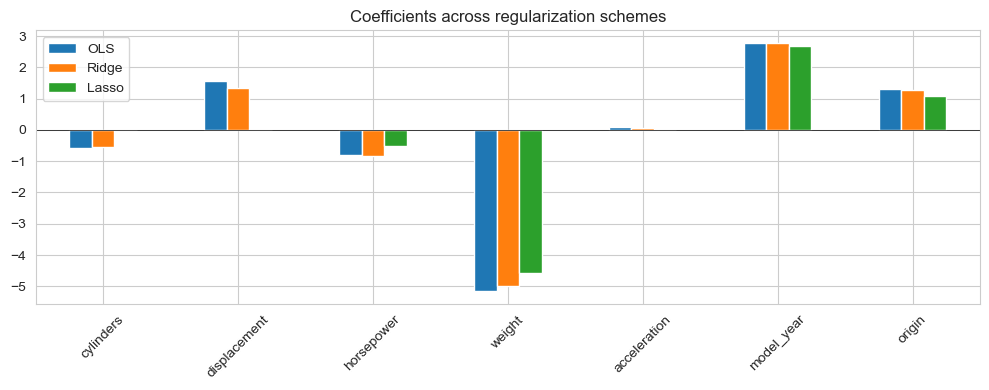

,OLS,Ridge,Lasso
cylinders,-0.587,-0.536,-0.000
displacement,1.565,1.345,-0.000
horsepower,-0.814,-0.847,-0.523
weight,-5.158,-4.983,-4.587
acceleration,0.107,0.070,0.000
model_year,2.783,2.762,2.670
origin,1.300,1.288,1.078


In [7]:
coefs = pd.DataFrame(
    {name: m.coef_ for name, m in models.items()},
    index=df.drop(columns="mpg").columns,
)

coefs.plot(kind="bar", figsize=(10, 4))
plt.title("Coefficients across regularization schemes")
plt.axhline(0, color="k", lw=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

coefs.round(3)

Note how **Lasso** drives some coefficients toward zero — that's the L1 penalty's feature-selection behavior.

## 6. Predicted vs Actual

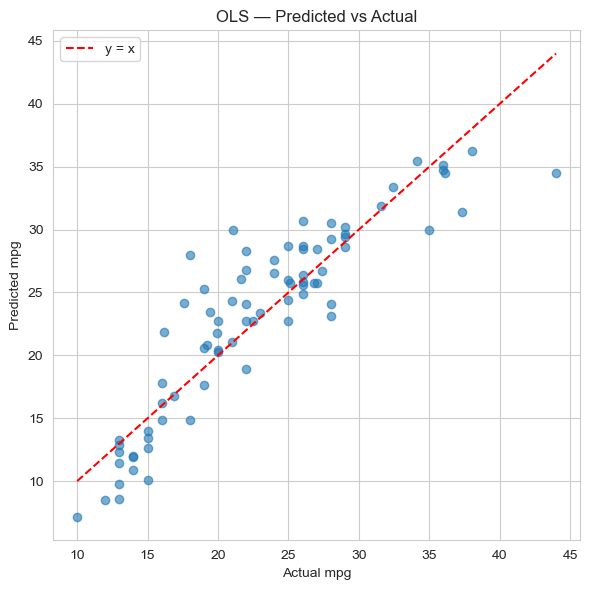

In [8]:
best = LinearRegression().fit(X_train_s, y_train)

preds = best.predict(X_test_s)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.6)

lo, hi = y_test.min(), y_test.max()
plt.plot([lo, hi], [lo, hi], "r--", label="y = x")

plt.xlabel("Actual mpg")
plt.ylabel("Predicted mpg")
plt.title("OLS — Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

## Takeaways
- All three regularization schemes yield similar performance, with R² around 0.79. Auto MPG has a relatively clean linear signal.
- `weight` and `model_year` are the strongest predictors. Heavier cars tend to have lower mpg, while newer cars tend to have higher mpg.
- Lasso drives some coefficients to zero, which is useful when you want a simpler model.
- Linear regression is a strong baseline. Beating it would likely require a non-linear model like a random forest.
